## Thomas Algorithm

In [13]:
# **NOTE** I used the internet and AI for reference to see how to make a Thomas Algorithm
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 0.8, 0.9, 0.1, -0.8, -1.0], dtype=float)

def thomas_algorithm(a, b, c, d):
    n = len(d)

    c_prime = np.zeros(n)
    d_prime = np.zeros(n)
    x = np.zeros(n)

    c_prime[0] = c[0] / b[0]
    d_prime[0] = d[0] / b[0]

    for i in range(1, n):
        denom = b[i] - a[i] * c_prime[i - 1]
        if i < n - 1:
            c_prime[i] = c[i] / denom
        d_prime[i] = (d[i] - a[i] * d_prime[i - 1]) / denom

    x[-1] = d_prime[-1]
    for i in range(n - 2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i + 1]

    return x

## Cubic Spline Setup

In [14]:
def cubic_spline_setup(x, y):
    n = len(x)
    h = np.diff(x)

    a = np.zeros(n)
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)

    b[0] = 1
    b[-1] = 1
    d[0] = 0
    d[-1] = 0

    for i in range(1, n - 1):
        a[i] = h[i - 1]
        b[i] = 2 * (h[i - 1] + h[i])
        c[i] = h[i]
        d[i] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    M = thomas_algorithm(a, b, c, d)
    return h, M

## Evaluate Spline Setup

In [17]:
def evaluate_spline(x, y, h, M, xeval):
    xeval = np.array(xeval)
    yeval = np.zeros_like(xeval, dtype=float)

    for j in range(len(xeval)):
        xe = xeval[j]

        if xe <= x[0]:
            i = 0
        elif xe >= x[-1]:
            i = len(x) - 2
        else:
            for k in range(len(x) - 1):
                if x[k] <= xe <= x[k + 1]:
                    i = k
                    break

        hi = h[i]
        xi = x[i]
        xi1 = x[i + 1]
        yi = y[i]
        yi1 = y[i + 1]
        Mi = M[i]
        Mi1 = M[i + 1]

        term1 = Mi * (xi1 - xe)**3 / (6 * hi)
        term2 = Mi1 * (xe - xi)**3 / (6 * hi)
        term3 = (yi - Mi * hi**2 / 6) * (xi1 - xe) / hi
        term4 = (yi1 - Mi1 * hi**2 / 6) * (xe - xi) / hi

        yeval[j] = term1 + term2 + term3 + term4

    return yeval

## Run, Plot, and Print

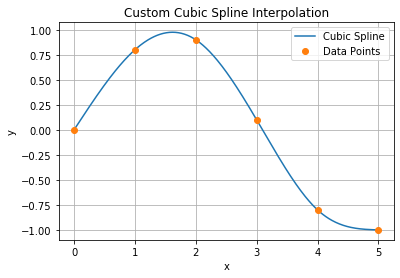

Second derivatives M:
[ 0.         -0.76937799 -1.12248804 -0.14066986  1.08516746  0.        ]


In [18]:
h, M = cubic_spline_setup(x, y)

xeval = np.linspace(x[0], x[-1], 400)
yeval = evaluate_spline(x, y, h, M, xeval)

plt.plot(xeval, yeval, label="Cubic Spline")
plt.plot(x, y, "o", label="Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Custom Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()

print("Second derivatives M:")
print(M)

As we can see, there is a smooth curve produced from the cubic spline hitting all the data points. Additionally, the derivatives start and end with 0, which checks out.